# $(SA) Triplet$

<!-- $loss = mse(\hat{\theta'},\hat{\theta}) + mse(\hat{s''},s'') + mse(\hat{s'''},y)$  -->
$loss = max\{||\hat{\theta_i^a} - \hat{\theta_j^a}|| - ||\hat{\theta_i^a} - \hat{\theta_k^b}|| + \alpha, 0\}$

## Experimento Validação

- 100 episódios de Treino
- 10 episódios de Validação
- 1 agente

* Cada agente é treinado com 800 passos dos episódios de treino e testado em 200, os passos de todos os episodios sao embaralhados aleatoriamente
* Resultado intermedário é uma comparacao do parametro estimado em cada passo de teste com o parametro real
* Os a gentes são validados em cada passo dos episódios de validação
* Resultado final é comparacao do parametro estimado em cada passo pelos agentes com o parametro real

In [1]:
import matplotlib.pyplot as plt

from pmbrl.model2 import Model, Triplet_Loss
from pmbrl.data import Experiment_Data, get_data_expanded

# Training

In [2]:
data = Experiment_Data()

data.load(path='training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
91,18,2,"(0.01, 1.0)","(-0.028, -0.775, 0.025, 0.558)",0,1.0,"(-0.043, -0.963, 0.036, 0.699)",0.0,1.0,"(-0.063, -1.151, 0.05, 0.842)"
244,18,9,"(0.92, 0.9)","(0.028, -0.401, -0.033, 0.39)",1,1.0,"(0.02, -0.201, -0.025, -0.03)",0.0,1.0,"(0.016, -0.4, -0.026, 0.365)"
197,10,6,"(0.87, 1.6)","(0.035, 0.751, -0.056, -0.887)",1,1.0,"(0.05, 0.943, -0.073, -1.107)",1.0,1.0,"(0.069, 1.135, -0.096, -1.331)"
14,14,0,"(0.18, 1.6)","(-0.077, -0.789, 0.084, 0.474)",1,1.0,"(-0.093, -0.603, 0.093, 0.386)",1.0,1.0,"(-0.105, -0.417, 0.101, 0.299)"
97,24,2,"(0.01, 1.0)","(-0.155, -1.153, 0.118, 0.887)",1,1.0,"(-0.178, -0.966, 0.136, 0.768)",0.0,1.0,"(-0.197, -1.154, 0.151, 0.924)"
...,...,...,...,...,...,...,...,...,...,...
161,14,5,"(0.43, 0.0)","(0.042, 0.024, 0.005, 0.134)",1,1.0,"(0.043, 0.223, 0.007, -0.249)",0.0,1.0,"(0.047, 0.024, 0.002, 0.139)"
121,20,3,"(0.63, 1.6)","(-0.212, -0.415, 0.192, 0.58)",0,1.0,"(-0.22, -0.605, 0.203, 0.753)",1.0,1.0,"(-0.232, -0.418, 0.218, 0.642)"
109,8,3,"(0.63, 1.6)","(-0.068, -0.783, 0.052, 0.646)",0,1.0,"(-0.084, -0.971, 0.065, 0.803)",1.0,1.0,"(-0.103, -0.783, 0.081, 0.665)"
24,24,0,"(0.18, 1.6)","(-0.12, -0.049, 0.128, 0.204)",1,1.0,"(-0.121, 0.136, 0.132, 0.121)",1.0,1.0,"(-0.118, 0.322, 0.135, 0.039)"


In [ ]:
model = Model(transition_criterion_clss=Triplet_Loss)

loss_param=1e-5

x, y = model.get_features_targets(data.training_dataset)
trainer = model.train(x, y, num_epochs=5000, margin=.5)
train_data = data.get_training_data(trainer, inference_schema=model.inference_schema)
train_data.head()

,epoch,triplet,mse_s,transition,reward
0,0,1.049004,"[0.06898101419210434, 0.3390447497367859, 0.14...",2.185021,0.280658
1,1,1.048609,"[0.0673326849937439, 0.3365801274776459, 0.142...",2.170844,0.280219
2,2,1.048212,"[0.06571853160858154, 0.33412107825279236, 0.1...",2.156784,0.279787
3,3,1.047815,"[0.06413104385137558, 0.33166855573654175, 0.1...",2.142833,0.279362
4,4,1.047419,"[0.06256931275129318, 0.32922136783599854, 0.1...",2.128986,0.278942


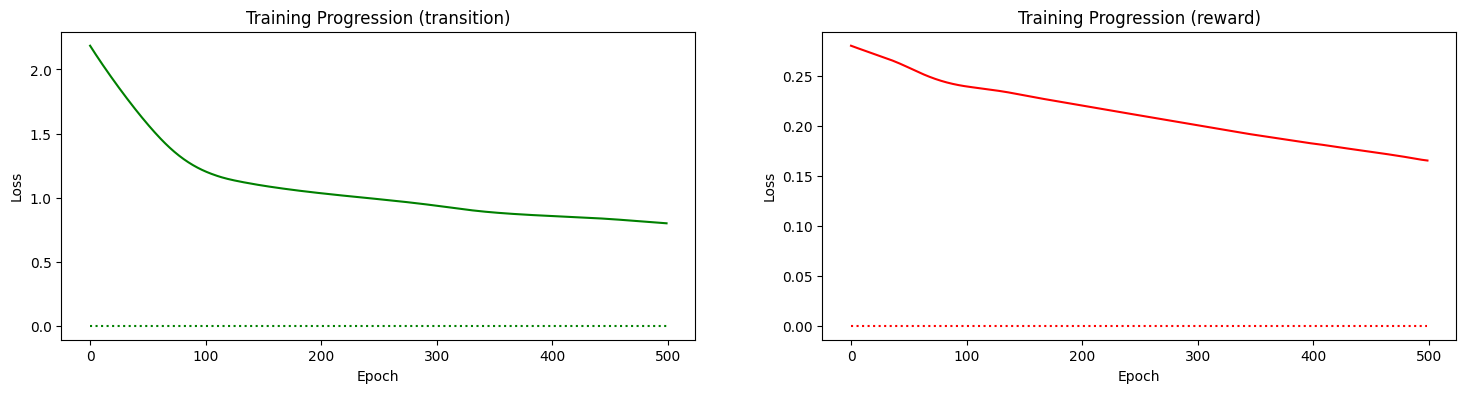

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(18, 4))

data.plot_training_loss(axs[0])
data.plot_training_loss(axs[1], train_data.reward, 'r')

plt.show()

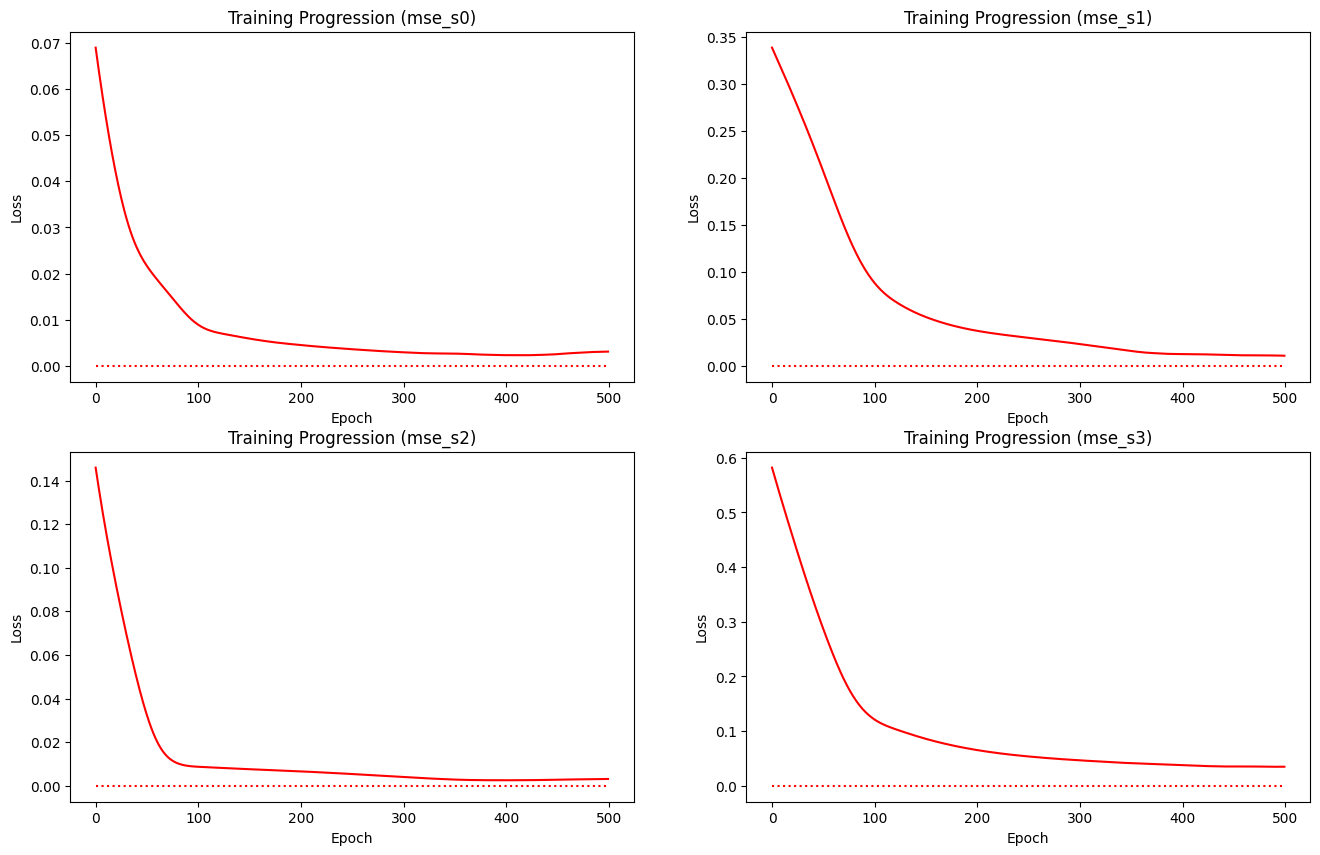

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))

expansions = {
    'mse_s': ['mse_s0', 'mse_s1', 'mse_s2', 'mse_s3'],
}

df = get_data_expanded(train_data, expansions)

for i,col in enumerate(expansions['mse_s']):
    data.plot_training_loss(axs[i//2][i%2], df[col], 'r')

plt.show()

In [6]:
df.head()

,epoch,triplet,mse_s,transition,reward,mse_s0,mse_s1,mse_s2,mse_s3
0,0,1.049004,"[0.06898101419210434, 0.3390447497367859, 0.14...",2.185021,0.280658,0.068981,0.339045,0.145911,0.582080
1,1,1.048609,"[0.0673326849937439, 0.3365801274776459, 0.142...",2.170844,0.280219,0.067333,0.336580,0.142750,0.575572
2,2,1.048212,"[0.06571853160858154, 0.33412107825279236, 0.1...",2.156784,0.279787,0.065719,0.334121,0.139651,0.569081
3,3,1.047815,"[0.06413104385137558, 0.33166855573654175, 0.1...",2.142833,0.279362,0.064131,0.331669,0.136613,0.562606
4,4,1.047419,"[0.06256931275129318, 0.32922136783599854, 0.1...",2.128986,0.278942,0.062569,0.329221,0.133629,0.556148


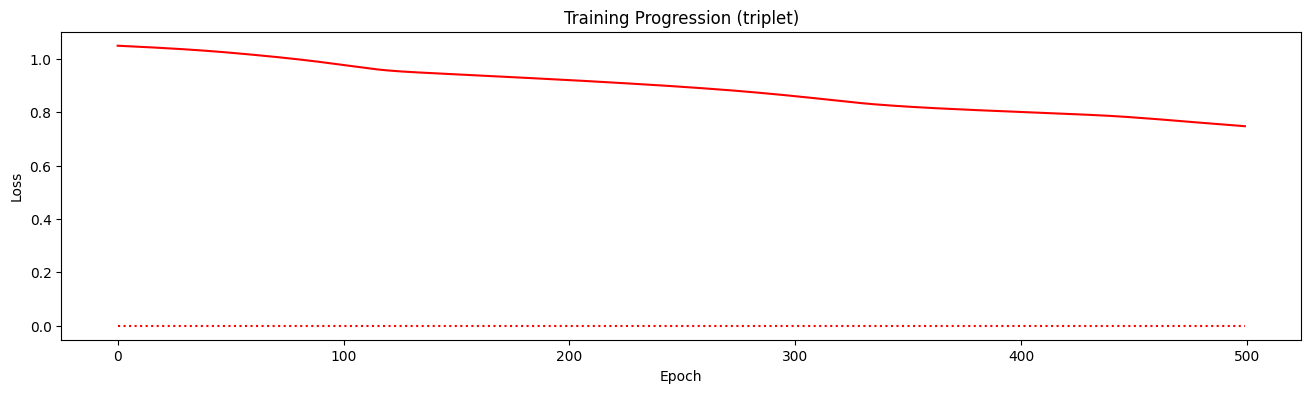

In [7]:
fig, axs = plt.subplots(1, 1, figsize=(16, 4))

data.plot_training_loss(axs, df['triplet'], 'r')

plt.show()

# Evaluation

In [8]:
results = data.evaluate_model(model, path='testing_data.csv')
results.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,estimated_s,estimated_p,estimated_r
0,0,0,"(0.49, 0.0)","(0.005, 0.039, -0.028, -0.013)",1,1.0,"(0.006, 0.24, -0.028, -0.434)",1.0,1.0,"(0.011, 0.441, -0.037, -0.856)","(0.046, 0.495, -0.064, -0.766)","(0.306, 0.535)",0.6
1,1,0,"(0.49, 0.0)","(0.006, 0.24, -0.028, -0.434)",1,1.0,"(0.011, 0.441, -0.037, -0.856)",0.0,1.0,"(0.019, 0.241, -0.054, -0.463)","(0.068, 0.263, -0.087, -0.603)","(0.456, 0.447)",0.6
2,2,0,"(0.49, 0.0)","(0.011, 0.441, -0.037, -0.856)",0,1.0,"(0.019, 0.241, -0.054, -0.463)",1.0,1.0,"(0.024, 0.442, -0.063, -0.896)","(0.081, 0.388, -0.06, -0.709)","(0.529, 0.521)",0.6
3,3,0,"(0.49, 0.0)","(0.019, 0.241, -0.054, -0.463)",1,1.0,"(0.024, 0.442, -0.063, -0.896)",1.0,1.0,"(0.033, 0.644, -0.081, -1.331)","(0.101, 0.701, -0.117, -1.171)","(0.493, 0.341)",0.7
4,4,0,"(0.49, 0.0)","(0.024, 0.442, -0.063, -0.896)",1,1.0,"(0.033, 0.644, -0.081, -1.331)",1.0,1.0,"(0.046, 0.846, -0.108, -1.774)","(0.146, 0.893, -0.149, -1.509)","(0.656, 0.218)",0.7


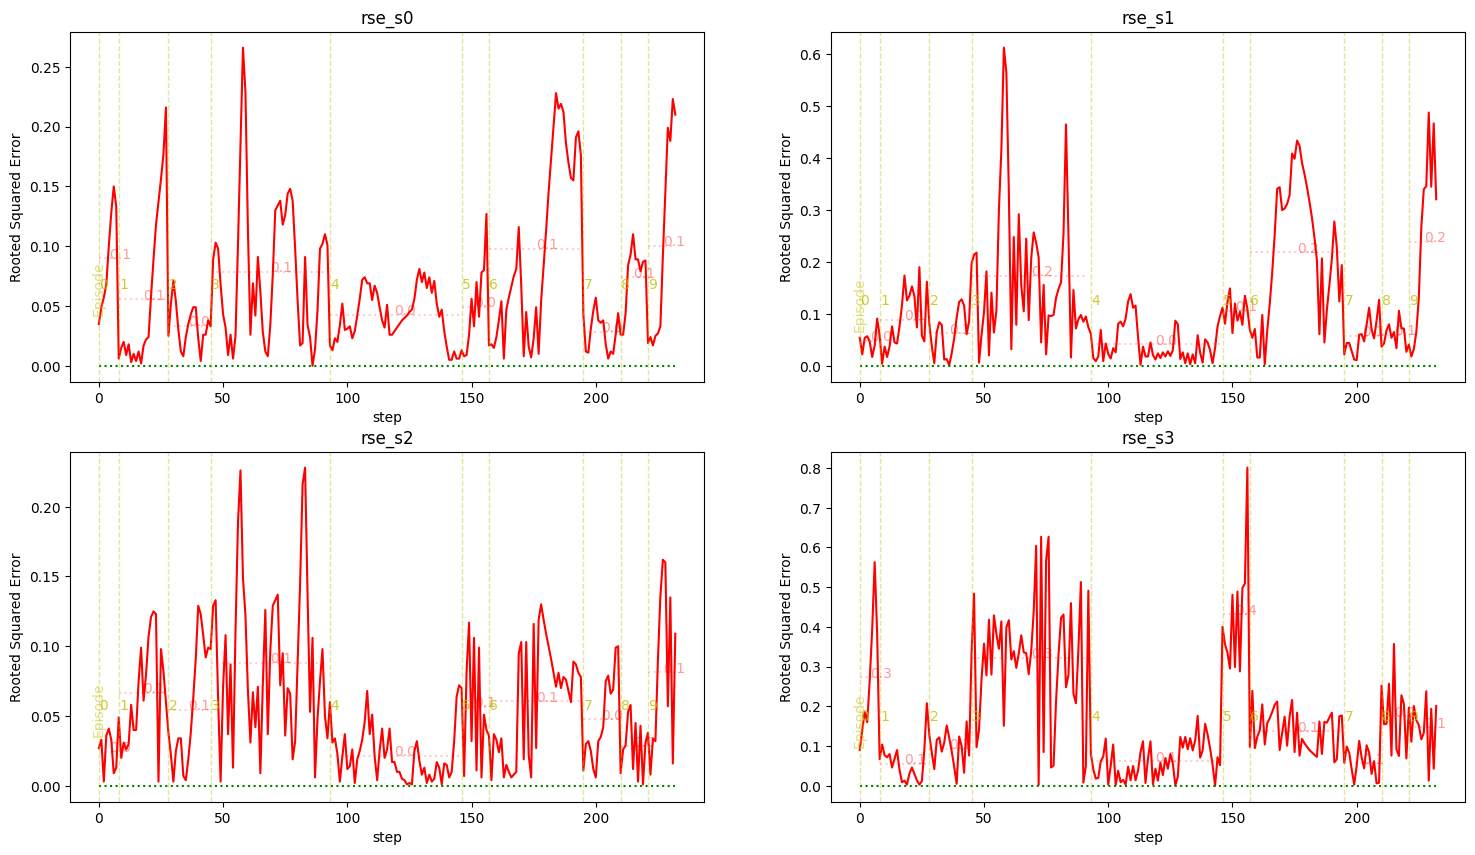

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(18,10))

data.plot_value_through_episodes(axs[0][0], results, 'rse_s0')
data.plot_value_through_episodes(axs[0][1], results, 'rse_s1')
data.plot_value_through_episodes(axs[1][0], results, 'rse_s2')
data.plot_value_through_episodes(axs[1][1], results, 'rse_s3')

plt.show()

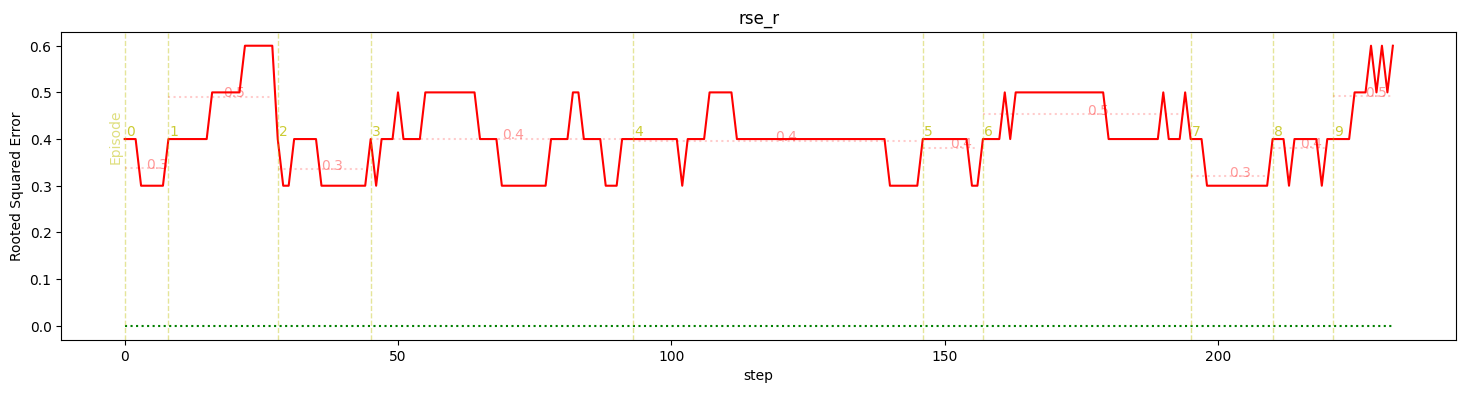

In [10]:
fig, axs = plt.subplots(1, 1, figsize=(18,4))
data.plot_value_through_episodes(axs, results, 'rse_r')
plt.show()

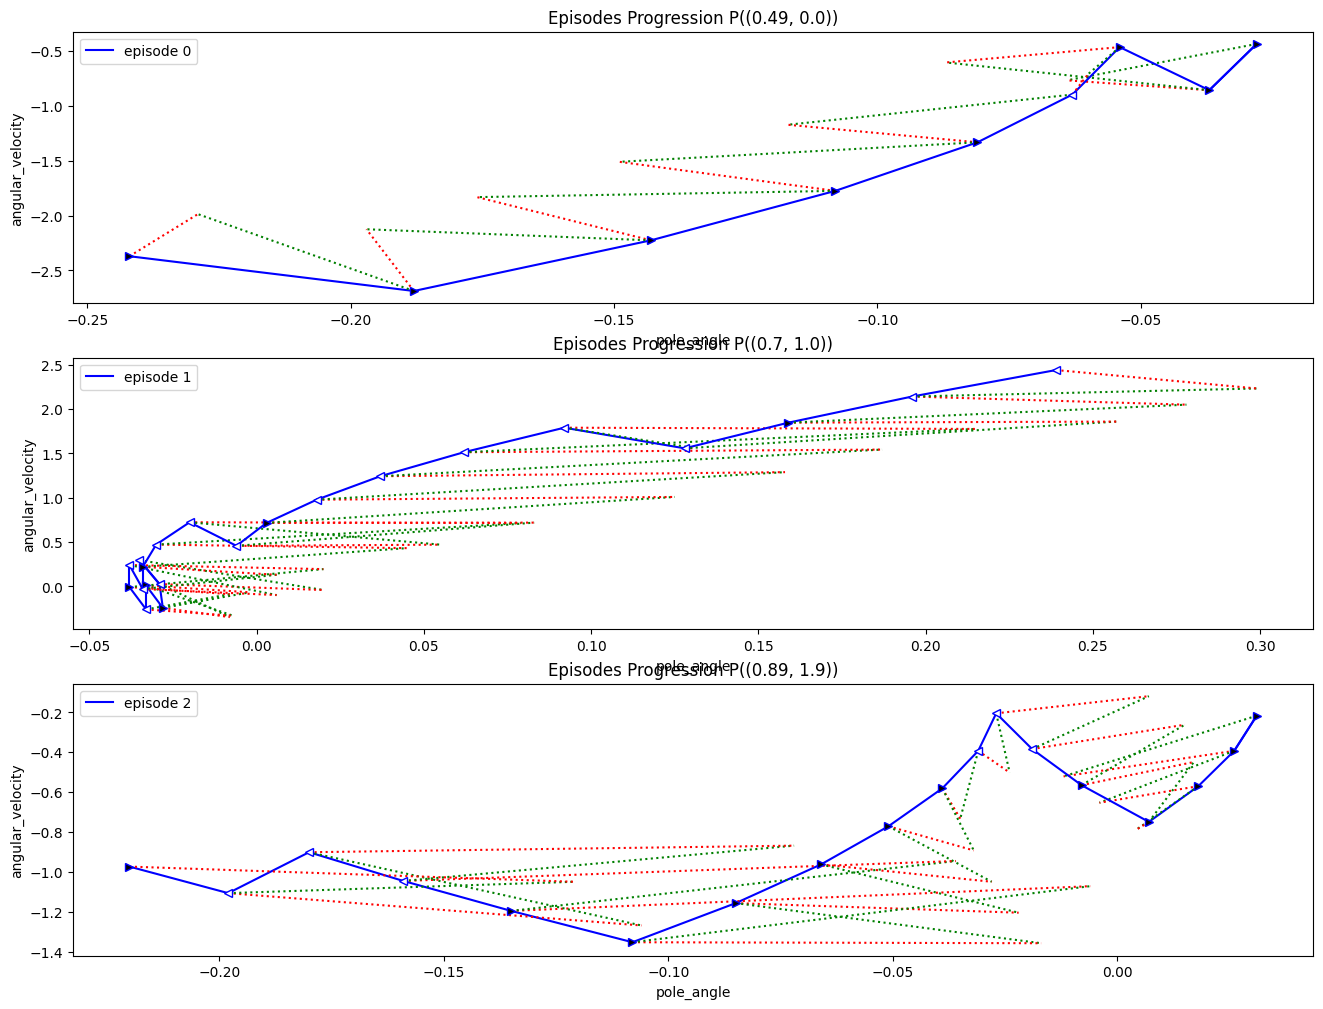

In [11]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(3, 1, figsize=(16, 12))
data.plot_episode_progression_with_predictions(axs[0], 0)
data.plot_episode_progression_with_predictions(axs[1], 1)
data.plot_episode_progression_with_predictions(axs[2], 2)
plt.show()